# 使用 DropoutPLIFSNN 训练 NinaPro 泊松脉冲

本 Notebook 兼容 `raw_data_poisson_spikes` 中的 `offset_128` 与 `polarity_split` 编码，以及 `T=40/80/120` 三种时间步。`offset_128` 输入为 `[B, 16, T]`，`polarity_split` 输入为 `[B, 32, T]`；全连接 `DropoutPLIFSNN` 直接使用对应通道，不进行二维重塑。

按照项目现有训练协议，每个 epoch 在测试集上评估并按测试准确率保存 `best.pt`。因此该结果属于 **test-selected checkpoint**，不应解释为完全无偏的泛化估计。

In [1]:
from pathlib import Path


def find_project_root():
    """从当前目录向上查找项目根目录。"""
    current = Path.cwd().resolve()
    for candidate in (current, *current.parents):
        if (candidate / "src").is_dir() and (candidate / "ninapro_data").is_dir():
            return candidate
    raise FileNotFoundError("未找到同时包含 src 与 ninapro_data 的项目根目录")


PROJECT_ROOT = find_project_root()

import sys
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"PROJECT_ROOT = {PROJECT_ROOT}")

PROJECT_ROOT = /root/autodl-tmp/NinaPro


## 1. 实验参数

In [2]:
# 修改这两个参数即可选择编码方法与已有时间步数据。
ENCODING = "polarity_split"  # 可选值: "offset_128", "polarity_split"
T = 40
AVAILABLE_ENCODINGS = {"offset_128": 16, "polarity_split": 32}
AVAILABLE_TIME_STEPS = (40, 80, 120)

NUM_WORKERS = 8
BATCH_SIZE = 128
EPOCHS = 120
LEARNING_RATE = 1e-2
WEIGHT_DECAY = 1e-4
GRADIENT_CLIP = 1.0
WARMUP_EPOCHS = 5
SEED = 42
DETERMINISTIC = False
MIXED_PRECISION = True
EVAL_INTERVAL = 1
CHECKPOINT_INTERVAL = 5
FAST_MODE = True
PREFER_CUPY = True
GPU_RESIDENT_DATA = True

HIDDEN_SIZE = 256
NUM_CLASSES = 12
TAU = 2.0
DROPOUT_RATE = 0.1

RUN_OVERFIT_CHECK = False
OVERFIT_MAX_STEPS = 500
OVERFIT_TARGET_ACCURACY = 0.99
OVERFIT_SAMPLES_PER_CLASS = 2
RESUME_FROM = None

In [3]:
if ENCODING not in AVAILABLE_ENCODINGS:
    raise ValueError(
        f"ENCODING={ENCODING!r} 不可用，可选值为 {tuple(AVAILABLE_ENCODINGS)}"
    )
if T not in AVAILABLE_TIME_STEPS:
    raise ValueError(
        f"T={T} 没有对应的预编码数据，可选值为 {AVAILABLE_TIME_STEPS}"
    )

INPUT_CHANNELS = AVAILABLE_ENCODINGS[ENCODING]
DATA_DIR = (
    PROJECT_ROOT
    / "ninapro_data"
    / "raw_data_poisson_spikes"
    / ENCODING
    / f"T_{T}"
)
MODEL_NAME = "DropoutPLIFSNN"
EXPERIMENT_NAME = (
    f"{MODEL_NAME}_BATCH_SIZE{BATCH_SIZE}_LR{LEARNING_RATE}"
    f"_INPUT{INPUT_CHANNELS}_HIDDEN{HIDDEN_SIZE}"
    f"_DROPOUT{DROPOUT_RATE}_TAU{TAU}_WD{WEIGHT_DECAY}"
)
OUTPUT_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "poisson_spike_ninapro_snn"
    / ENCODING
    / f"T_{T}"
    / EXPERIMENT_NAME
)

print(f"ENCODING = {ENCODING}")
print(f"T = {T}, INPUT_CHANNELS = {INPUT_CHANNELS}")
print(f"DATA_DIR = {DATA_DIR}")
print(f"OUTPUT_DIR = {OUTPUT_DIR}")

ENCODING = polarity_split
T = 40, INPUT_CHANNELS = 32
DATA_DIR = /root/autodl-tmp/NinaPro/ninapro_data/raw_data_poisson_spikes/polarity_split/T_40
OUTPUT_DIR = /root/autodl-tmp/NinaPro/outputs/poisson_spike_ninapro_snn/polarity_split/T_40/DropoutPLIFSNN_BATCH_SIZE128_LR0.01_INPUT32_HIDDEN256_DROPOUT0.1_TAU2.0_WD0.0001


## 2. 随机种子与设备

In [4]:
from src.training import resolve_device, seed_everything

seed_everything(SEED, deterministic=DETERMINISTIC)
DEVICE = resolve_device()
print(f"DEVICE = {DEVICE}")

DEVICE = cuda


## 3. 加载二值泊松脉冲

In [5]:
import torch
from torch.utils.data import DataLoader

from src.data import NinaProWindowDataset

# 预编码数据保持 0/1，不应用原始 sEMG 数据使用的 Z-score。
train_dataset = NinaProWindowDataset(DATA_DIR / "train.npz", transform=None)
test_dataset = NinaProWindowDataset(DATA_DIR / "test.npz", transform=None)

expected_shape = (INPUT_CHANNELS, T)
for split_name, dataset in (("train", train_dataset), ("test", test_dataset)):
    sample, target = dataset[0]
    if tuple(sample.shape) != expected_shape:
        raise ValueError(
            f"{split_name} 样本形状应为 {expected_shape}，实际为 {tuple(sample.shape)}"
        )
    if sample.min() < 0 or sample.max() > 1:
        raise ValueError(f"{split_name} 数据不是 0/1 泊松脉冲")
    print(
        f"{split_name}: samples={len(dataset):,}, sample shape={tuple(sample.shape)}"
    )

loader_options = {
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "pin_memory": DEVICE.type == "cuda",
}
if NUM_WORKERS > 0:
    loader_options["persistent_workers"] = True

train_loader = DataLoader(
    train_dataset,
    shuffle=True,
    drop_last=False,
    generator=torch.Generator().manual_seed(SEED),
    **loader_options,
)
test_loader = DataLoader(
    test_dataset,
    shuffle=False,
    drop_last=False,
    generator=torch.Generator().manual_seed(SEED + 1),
    **loader_options,
)

train: samples=17,839, sample shape=(32, 40)
test: samples=8,787, sample shape=(32, 40)


## 4. DropoutPLIFSNN

In [6]:
from src.models import DropoutPLIFSNN

model = DropoutPLIFSNN(
    input_channels=INPUT_CHANNELS,
    hidden_size=HIDDEN_SIZE,
    num_classes=NUM_CLASSES,
    tau=TAU,
    dropout_rate=DROPOUT_RATE,
)
parameter_count = sum(parameter.numel() for parameter in model.parameters())
print(model)
print(f"parameters = {parameter_count:,}")

DropoutPLIFSNN(
  input_channels=32, hidden_size=256, num_classes=12, tau=2.0, step_mode='m', backend='torch', auto_reset=True, dropout_rate=0.1
  (input_projection): Linear(in_features=32, out_features=256, bias=True)
  (lif1): ParametricLIFNode(
    v_threshold=1.0, v_reset=0.0, detach_reset=True, step_mode=m, backend=torch, tau=2.0
    (surrogate_function): ATan(alpha=2.0, spiking=True)
  )
  (hidden_projection): Linear(in_features=256, out_features=256, bias=True)
  (lif2): ParametricLIFNode(
    v_threshold=1.0, v_reset=0.0, detach_reset=True, step_mode=m, backend=torch, tau=2.0
    (surrogate_function): ATan(alpha=2.0, spiking=True)
  )
  (classifier): Linear(in_features=256, out_features=12, bias=True)
  (dropout1): Dropout(p=0.1)
  (dropout2): Dropout(p=0.1)
)
parameters = 77,326


## 5. 可选的单批次过拟合诊断

In [7]:
import copy

from src.training import overfit_one_batch

diagnostic_history = None
if RUN_OVERFIT_CHECK:
    diagnostic_indices = []
    for class_index in range(NUM_CLASSES):
        class_indices = torch.nonzero(
            train_dataset.labels == class_index,
            as_tuple=False,
        ).flatten()
        diagnostic_indices.extend(
            class_indices[:OVERFIT_SAMPLES_PER_CLASS].tolist()
        )
    diagnostic_samples = [train_dataset[index] for index in diagnostic_indices]
    diagnostic_batch = (
        torch.stack([sample for sample, _ in diagnostic_samples]),
        torch.stack([target for _, target in diagnostic_samples]),
    )
    diagnostic_model = copy.deepcopy(model)
    diagnostic_history = overfit_one_batch(
        diagnostic_model,
        diagnostic_batch,
        max_steps=OVERFIT_MAX_STEPS,
        target_accuracy=OVERFIT_TARGET_ACCURACY,
        learning_rate=LEARNING_RATE,
        gradient_clip=GRADIENT_CLIP,
        device=DEVICE,
    )
    final_diagnostic = diagnostic_history[-1]
    print(
        f"diagnostic steps={len(diagnostic_history)}, "
        f"loss={final_diagnostic['loss']:.4f}, "
        f"accuracy={final_diagnostic['accuracy'] * 100:.2f}%"
    )

## 6. 正式训练

In [8]:
from src.training import fit

CLASS_NAMES = [
    "Index flexion", "Index extension", "Middle flexion", "Middle extension",
    "Ring flexion", "Ring extension", "Little flexion", "Little extension",
    "Thumb adduction", "Thumb abduction", "Thumb flexion", "Thumb extension",
]
experiment_config = {
    "seed": SEED,
    "deterministic": DETERMINISTIC,
    "data_dir": str(DATA_DIR),
    "encoding": ENCODING,
    "input_representation": f"poisson_{ENCODING}",
    "input_layout": "[B, C, T]",
    "normalization": "none_preserve_binary_spikes",
    "target_time_steps": T,
    "model": {
        "name": MODEL_NAME,
        "input_channels": INPUT_CHANNELS,
        "hidden_size": HIDDEN_SIZE,
        "num_classes": NUM_CLASSES,
        "tau": TAU,
        "dropout_rate": DROPOUT_RATE,
        "parameter_count": parameter_count,
    },
}

history = fit(
    model=model,
    train_loader=train_loader,
    test_loader=test_loader,
    output_dir=OUTPUT_DIR,
    epochs=EPOCHS,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    gradient_clip=GRADIENT_CLIP,
    device=DEVICE,
    mixed_precision=MIXED_PRECISION,
    normalization_state=None,
    config=experiment_config,
    resume_from=RESUME_FROM,
    class_names=CLASS_NAMES,
    warmup_epochs=WARMUP_EPOCHS,
    eval_interval=EVAL_INTERVAL,
    checkpoint_interval=CHECKPOINT_INTERVAL,
    fast_mode=FAST_MODE,
    prefer_cupy=PREFER_CUPY,
    gpu_resident_data=GPU_RESIDENT_DATA,
)

device=cuda, amp=True, backend=spikingjelly-cupy, gpu_resident_data=True, batch_size=128, epochs=1..120


Train 001/120:   0%|          | 0/140 [00:00<?, ?it/s]

Test  001/120:   0%|          | 0/69 [00:00<?, ?it/s]

epoch 001/120 | train loss 2.4489, acc 12.16% | test loss 2.4045, acc 14.35% | lr 2.000e-03 | 1.58s *


Train 002/120:   0%|          | 0/140 [00:00<?, ?it/s]

...

epoch 119/120 | train loss 0.9959, acc 66.41% | test loss 2.3824, acc 28.12% | lr 7.461e-06 | 0.90s


Train 120/120:   0%|          | 0/140 [00:00<?, ?it/s]

Test  120/120:   0%|          | 0/69 [00:00<?, ?it/s]

epoch 120/120 | train loss 0.9979, acc 66.59% | test loss 2.3826, acc 28.09% | lr 1.866e-06 | 1.45s


Best test:   0%|          | 0/69 [00:00<?, ?it/s]

## 7. 最佳测试结果

encoding         = polarity_split
T                = 40
best epoch       = 12
test accuracy    = 30.74%
macro precision  = 32.24%
macro recall     = 31.39%
macro F1         = 30.82%
注意：以上结果来自 test-selected checkpoint。


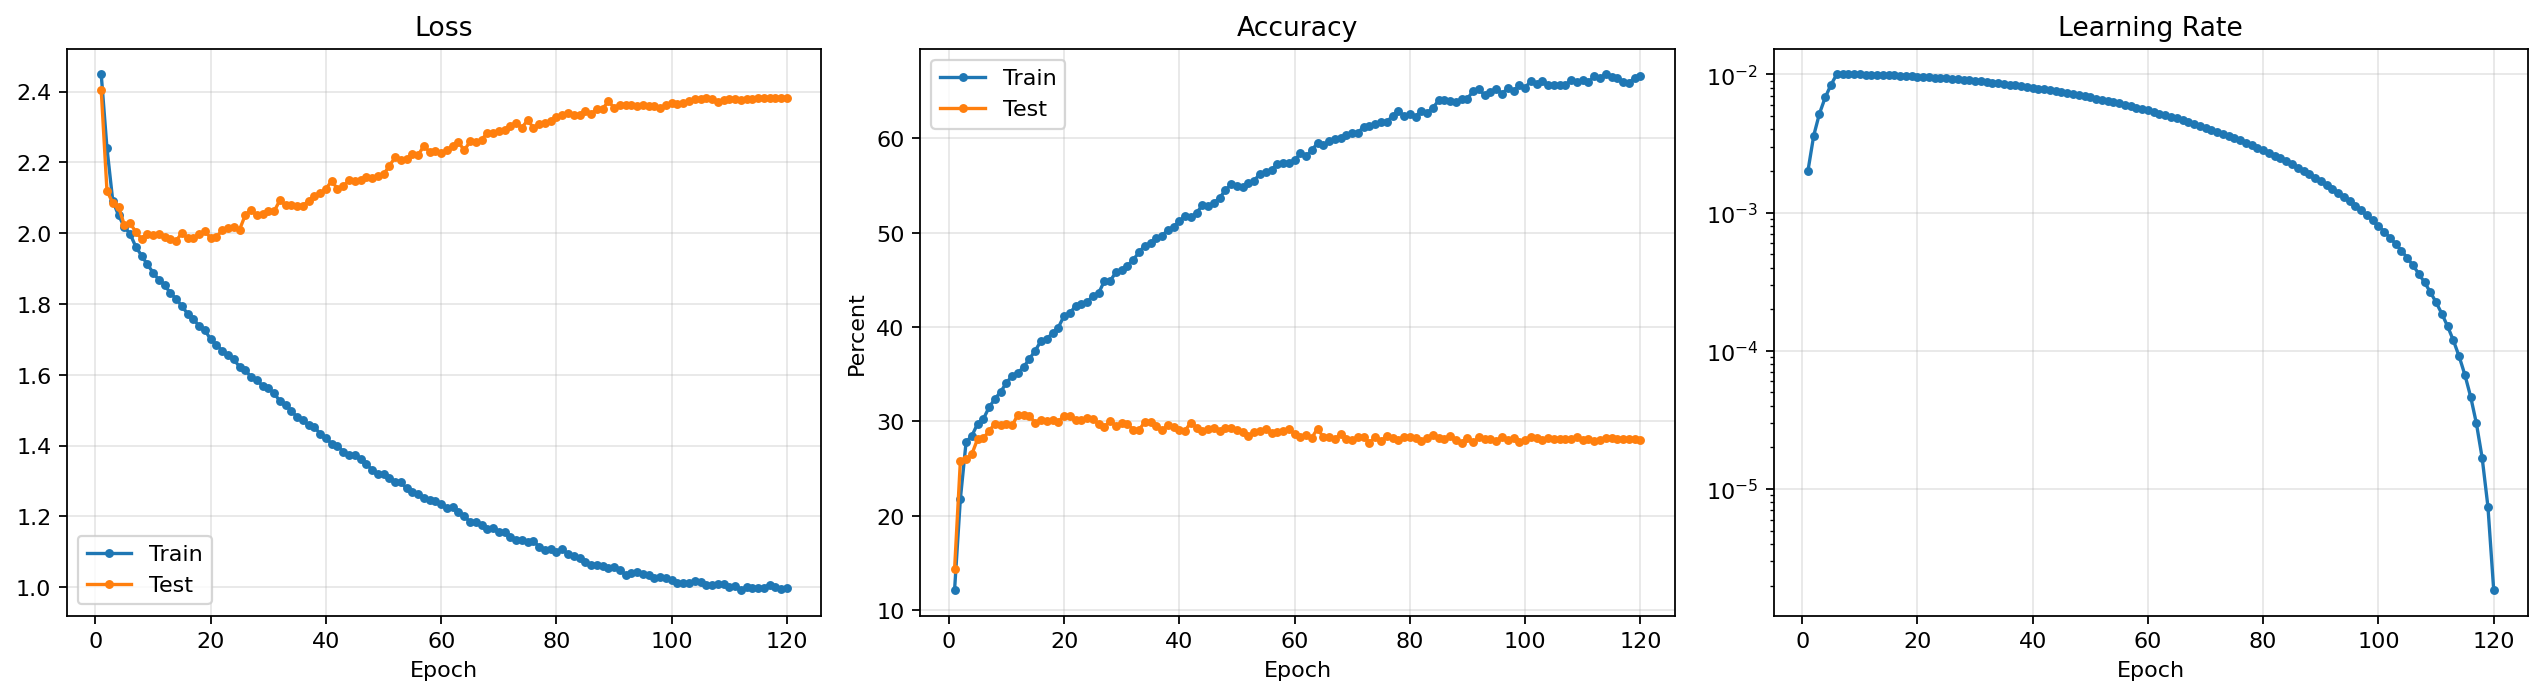

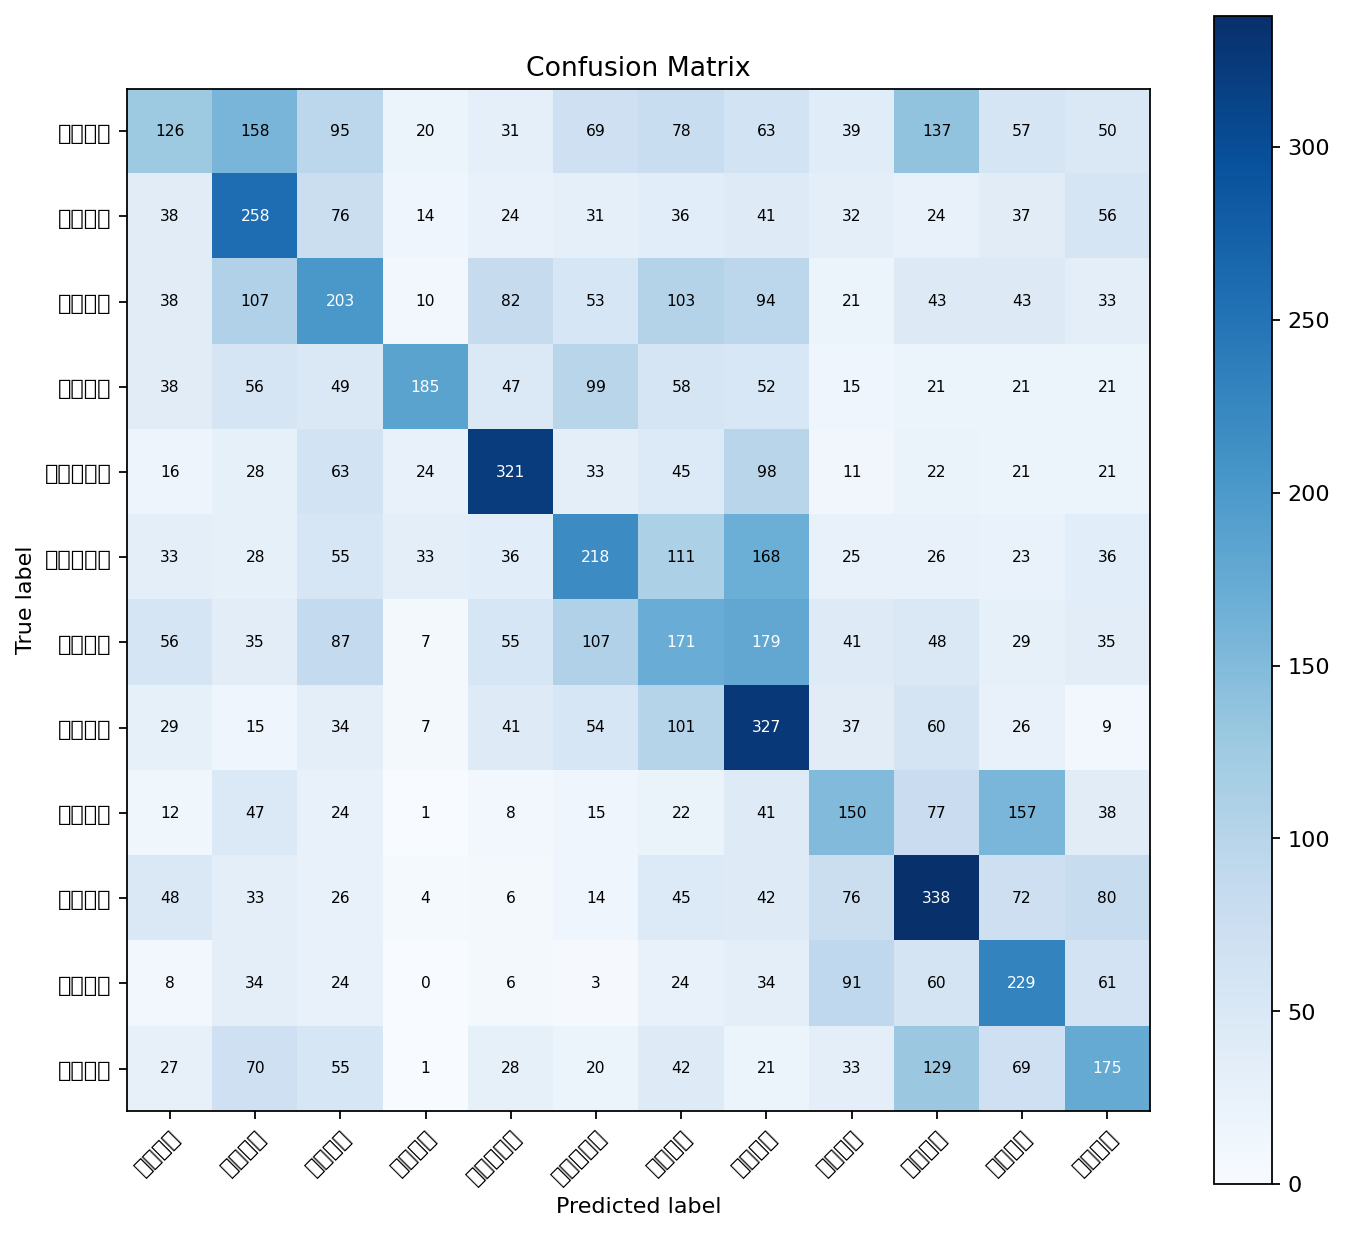

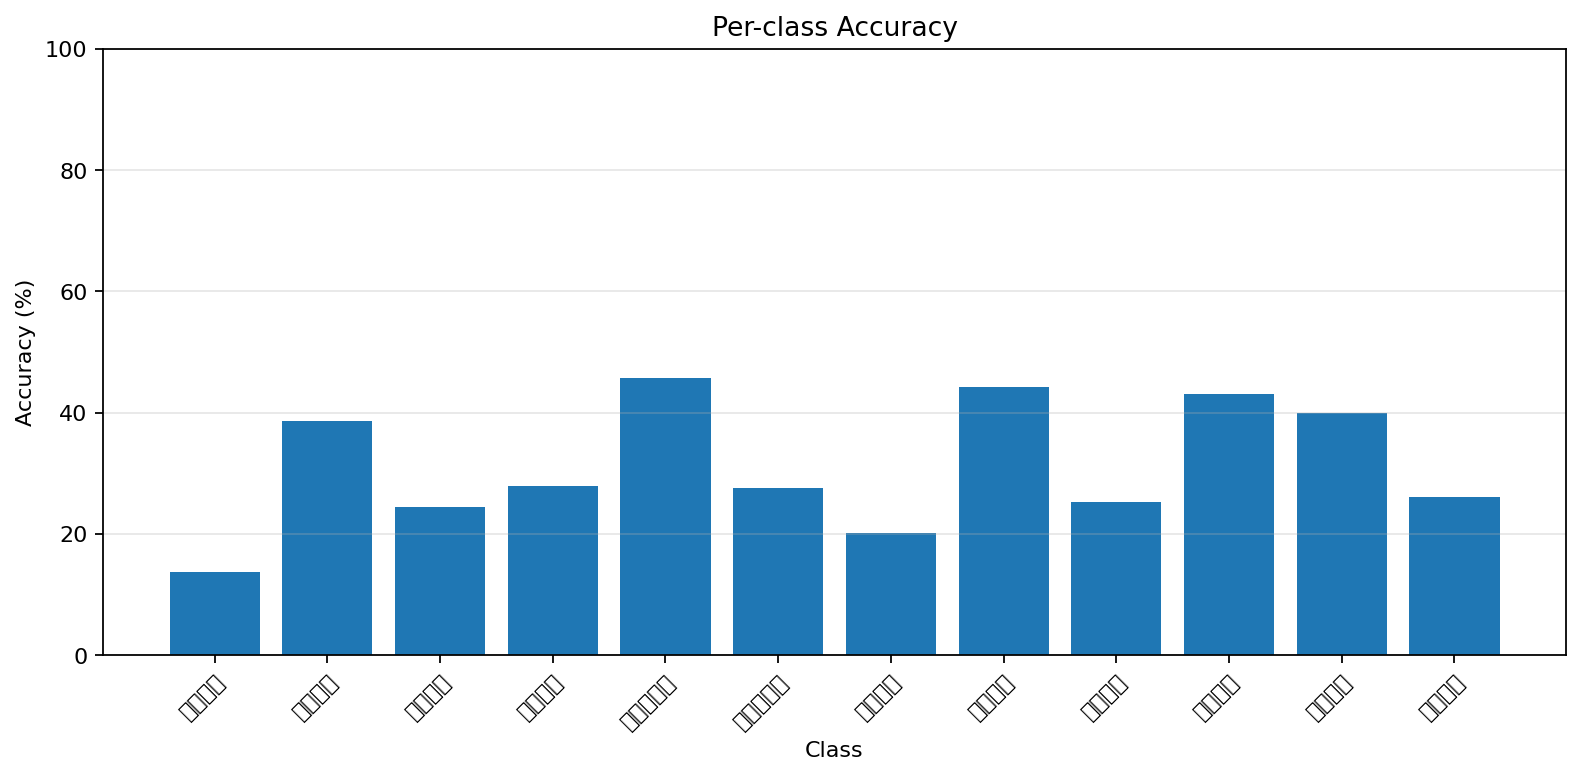

In [9]:
import json
from IPython.display import Image, display

metrics_path = OUTPUT_DIR / "metrics.json"
best_metrics = json.loads(metrics_path.read_text(encoding="utf-8"))
print(f"encoding         = {ENCODING}")
print(f"T                = {T}")
print(f"best epoch       = {best_metrics['best_epoch']}")
print(f"test accuracy    = {best_metrics['accuracy'] * 100:.2f}%")
print(f"macro precision  = {best_metrics['macro_precision'] * 100:.2f}%")
print(f"macro recall     = {best_metrics['macro_recall'] * 100:.2f}%")
print(f"macro F1         = {best_metrics['macro_f1'] * 100:.2f}%")
print("注意：以上结果来自 test-selected checkpoint。")

for filename in (
    "training_curves.png",
    "confusion_matrix.png",
    "per_class_accuracy.png",
):
    display(Image(filename=str(OUTPUT_DIR / "figures" / filename)))